In [90]:
# Numpy für bessere Berechnungen
import numpy as np
from numpy import exp, sqrt, log, pi
from uncertainties import unumpy as unp

# Weiteres für bessere Rechnungen
import pylab as py

from decimal import Decimal, ROUND_CEILING, ROUND_HALF_UP, getcontext # Besonders für sig. Runden
import math

# Berechnungen und Plotting
from scipy import odr
import scipy.optimize
import scipy.constants as c
from scipy.stats import norm
from scipy.optimize import curve_fit
from scipy.stats import chi2
from scipy.stats import poisson
from scipy.integrate import quad
from scipy.signal import find_peaks
from scipy.signal import argrelextrema, argrelmin, argrelmax
from scipy.special import factorial

%matplotlib widget
import matplotlib.pyplot as plt
from matplotlib import colormaps
import matplotlib.mlab as mlab
import matplotlib.transforms as transforms

# Zum Auslesen von Dateien und ähnlichem
import os
import os.path
from pathlib import Path

import pandas as pd # Auch wichtig für den Latex Export
from pytexit import py2tex
import csv
import re
from typing import List


# Besseres Funktionen handling
import sympy as sp
from sympy import separatevars

# Display und Output
from IPython.display import display, Math, Latex, HTML

import textwrap 

# Grafiken in EU-Größen ausgeben
def figsize_cm(width_cm, height_cm):
    return (2*width_cm / 2.54, 2*height_cm / 2.54)
def comma_to_float(valstr):
    return float(valstr.replace(',','.'))

g=9.80984 
Delta_g=0.00002


In [ ]:
currentversuch = "223"
base = Path.cwd()                   
Messwerte_path = Path(base.parent.parent.parent/"Messwerte"/currentversuch)      # initializing paths
Ausgabe_path = Path(base/"Diagramme")
print(Messwerte_path)
print(Ausgabe_path)



c:\Users\samue\OneDrive\Dokumente\PAP\PAP2.1\Messwerte\223
c:\Users\samue\OneDrive\Dokumente\PAP\PAP2.1\Auswertungen2.2\Code\242\Diagramme


Delete UTF8 False encoding

In [92]:
# def deletevocals(text):
#     text=textwrap.dedent(text)
#     patterna = r'[¨][a]'
#     text=re.sub(patterna,"ä",text)
#     patternu=r'[¨][u]'
#     text=re.sub(patternu,"ü",text)
#     patterno=r'[¨][o]'
#     text=re.sub(patterno,"ö",text)
#     return text

def deletevocals(text):
    # Einrückungen entfernen
    text = textwrap.dedent(text)
    #  entfernt Bindestriche
    text = re.sub(r'-\n\s*',"",text)
    # entfernt Zeilenumbrüche
    text = text.replace("\n", " ")
    
    # Eine Funktion, die vom re.sub aufgerufen wird, wenn ein Treffer erzielt wird
    def convert(match):
        # match.group(1) ist der Buchstabe nach dem Pünktchen (z.B. 'a' oder 'A')
        buchstabe = match.group(1)
        # Dictionary für die echten Umlaute
        umlaute = {'a': 'ä', 'u': 'ü', 'o': 'ö', 'A': 'Ä', 'U': 'Ü', 'O': 'Ö'}
        # Gib den Umlaut zurück. Falls das Zeichen nicht im Dict ist, lass es wie es ist
        return umlaute.get(buchstabe, buchstabe)
    # Das Pattern sucht nach ¨ gefolgt von einem beliebigen Buchstaben aus der Auswahl
    return re.sub(r'¨([auoAUO])', convert, text)

In [ ]:
print(deletevocals("""

"""))

 Spektralanteile, die für die ideal rechteckige Kontur essenziell sind. Die implementierte Gegenkopplung ermöglicht dank ihres vergleichsweise kleinen Widerstands dennoch steile Übergänge: Das ursprüngliche Rechteck bleibt erkennbar, da die niedrigen Frequenzen kaum gedämpft werden. Ein zusätzlicher Vorteil der Gegenkopplung besteht darin, dass sie das Überschwingen bei Laständerungen reduziert und somit ein stabileres Ausgangssignal liefert. 


Runden signifikanter Stellen

In [94]:
def round_to_sigs(val, errVal,einheiten):
    """
    Funktion zur Rundung eines Fehlers und die Anpassung des Messwertes daran. Diese Funktion wurde etwas umständlicher 
    geschrieben, da python mit Floats und Runden schnell in Probleme rennt. Daher musste hier mit dezimal gearbeitet werden.
    Zudem sollten besonders kleine und große Messwerte in der Dezimalschreibweise geschrieben werden, damit diese auch 
    für Protokolle geiegnet sind.

    Parameter
    ----------
    **val** : float
        Messwert

    **errVal** : float
        Ungenauigkeit des Messwertes

    Return
    ------
    **value_rounded** : str
        Gerundeter Messwert

    **error_rounded** : str
        Gerundete Ungenauigkeit des Messwertes

    **res** : str
        "Messwert \\pm Fehler"
    """

    # Daten zu Dezimal wechseln, da Floats probleme machen
    val = Decimal(str(val))
    errVal = Decimal(str(errVal))

    exp = int(math.floor(math.log10(float(errVal))))            # Die erste signifikante Stellenposition wird anhand des errVal bestimmt

    if round(float(errVal / (Decimal(10) ** exp))) < 3:         # wenn 1,2,3 erste signifikante Stelle, dann kommt eine zweite Nachkommastellenposition hinzu
        exp -= 1

    scale = Decimal(10) ** exp                                  

    val_round = (val / scale).quantize(Decimal('1'), rounding=ROUND_HALF_UP) * scale            # mit scale wird das Komma so verschoben, dass alle signifikanten Stellen vor dem Komma stehen, und dann alle Nachkommastellen weggerundet werden
    err_round = (errVal / scale).quantize(Decimal('1'), rounding=ROUND_CEILING) * scale

    qty = f"\\qty{{{val_round}({err_round})}}{{{einheiten}}}"
    num = f"\\num{{{val_round}({err_round})}}"
    return float(val_round), float(err_round), num, qty

v_round = np.vectorize(round_to_sigs, otypes=[float, float, object, object], excluded=['einheiten'])

    # wissenschaftliche Notation erstmal vernachlässigen (da häufig Einheiten gewollt sind, die 10^/e Prefixe beinhalten)

Gausssche Fehlerfortpflanzung

In [95]:
def gff(function, errPronePar,latex=True):
    """
    Kann die Fehlerformel einer gegebenen Gleichung bestimmen.

    Parameters
    ----------
    **func** : sympy function
        Funktion dessen Fehler bestimmt werden soll.

    **errPronePar** : Array
        Liste (Array) aller fehlerbehafteten Größen der Gleichung con sp.Symbols
        Diese Werte werden als x_sym, y_sym, z_sym etc. bezeichnet und sind ungleich den Werten für x, y, z.
        Für die Werte wird daher die Bezeichnung x_val, y_val, z_val etc. genutzt und für deren Fehler err_x, err_y, err_z etc.

    Return
    ----------
    **absolut_err** : sympy function
        Gibt die Fehlergleichung des absoluten Fehlers wieder. 

    **relativ_err** : sympy function
        Gibt die Fehlergleichung des relativen Fehlers wieder. 
        
    **errProneParamters** : array
        Liste aller Fehlerbehafteten Größen
    """ 

    error = 0
    errProneParamaters = []

    function = sp.sympify(function)
    variables = errPronePar.split(",")
    variables = sp.symbols(variables)

    for variable in variables:
        Delta = sp.Symbol(f"Delta_{variable}")
        partial = sp.diff(function, variable)                   # Die Funktion wird nach der fehlerbehafteten Variable abgeleitet
        term=sp.UnevaluatedExpr(partial*Delta)**2
        error = error + ((term))                                # Fehler werden quadratisch aufsummiert
        errProneParamaters.append((variable,Delta))
    
    absolute_err=sp.simplify(sp.sqrt(error),rational = True)             
    relative_err=sp.simplify(sp.sqrt(error/function**2),rational = True)
    
    if latex:
        #Prints out the Latex Code for the Functions
        print("Funktion:")
        display(Math(sp.latex(function,long_frac_ratio=2))) 
        print(sp.latex(function))
        print("Absoluter Fehler:")
        display(Math(sp.latex(absolute_err,long_frac_ratio=2)))
        print(sp.latex(absolute_err))
        print("Relativer Fehler:")
        display(Math(sp.latex(relative_err,long_frac_ratio=2)))
        print(sp.latex(relative_err))
    return function,absolute_err, relative_err, errProneParamaters


Sigma-Abweichungen

In [96]:
def sigma_abweichung(p1, err_p1,p2,err_p2):
    """
    Funktion zum berechnen der Sigma-Abweichugn von zwei Messwerten, oder einem Messwert und einem Literaturwert.
    """
    if err_p1 == 0 and err_p2 == 0:
        raise ValueError("Für die Sigma-Abweichung muss mindestens ein Wert fehlerbehaftet sein!")
    else:
        abweichung=Decimal(str(abs(p1 - p2)/(np.sqrt(err_p1 ** 2+err_p2 ** 2))))

    if abweichung == 0:
        return 0.0, "\\num{0}"
    
    exp = int(math.floor(math.log10(float(abweichung))))
    if round(float(abweichung / (Decimal(10) ** exp))) < 3:         # wenn 1,2,3 erste signifikante Stelle, dann kommt eine zweite Nachkommastellenposition hinzu
        exp -= 1
    scale = Decimal(10) ** exp   
    abweichung_round = (abweichung / scale).quantize(Decimal('1'), rounding=ROUND_CEILING) * scale
    res = f"\\num{{{abweichung_round}}}"

    return float(abweichung_round),res



In [121]:

# #Größenvergleich in latex
# def size_comp_str(name1,name2,val1,val2):
#     if val1<val2:
#         return name1+"<"+name2
#     elif val1>val2:
#         return name1+">"+name2
#     else:
#         return name1+"="+name2
   
#Erstellung von Vergleichstabellen in Latex
def compare_table_array(nam1, nam2, einheiten, val1_array, err1_array, val2_array, err2_array):
    # 1. Tabellenkopf (Hier werden die Strings einmalig eingesetzt)
    output_header = textwrap.dedent(f"""
        \\begin{{table}}[htb]
        \\centering
        \\caption{{Vergleich von {nam1} und {nam2}}}
        \\begin{{tabularx}}{{0.8\\textwidth}}{{ZZZZZ}}
            \\toprule
                 Messreihe & {nam1}[\\unit{{{einheiten}}}] & {nam2}[\\unit{{{einheiten}}}] & \\text{{abs.Abw.}}[\\unit{{{einheiten}}}] & \\text{{proz.Abw.}}[\\unit{{\\percent}}] & S[\\sigma] \\\\\\midrule
    """).strip()
    
    table_rows = []
    
    # 2. Der Body (Schleife läuft über die Werte-Arrays)
    for val1, err1, val2, err2 in zip(val1_array, err1_array, val2_array, err2_array):
        
        # Deine Berechnungen (bleiben exakt gleich)
        VAL1 = round_to_sigs(val1, err1, r'')[2]
        VAL2 = round_to_sigs(val2, err2, r'')[2]
        
        abs_val = np.abs(val1 - val2)
        abs_delta = np.sqrt(err1**2 + err2**2)
        
        if abs_delta != 0:
            SIGMA = sigma_abweichung(val1, err1, val2, err2)[1]
        else:
            SIGMA = 0.0
            
        ABS = round_to_sigs(abs_val, abs_delta, r'')[2]
        
        rel = abs_val / np.abs(val1) * 100 if val1 != 0 else 0
        rel_delta = rel * np.sqrt((abs_delta / abs_val)**2 + (err1 / val1)**2) if abs_val != 0 and val1 != 0 else 0
        REL = round_to_sigs(rel, rel_delta, r'')[2]

        # Eine saubere Zeile nur mit den Werten für LaTeX
        row = f"        & {VAL1} & {VAL2} & {ABS} & {REL} & {SIGMA} \\\\"
        table_rows.append(row)
    
    body_str = "\n".join(table_rows)
    
    # 3. Tabellenfuß
    output_footer = textwrap.dedent(f"""
                \\bottomrule
        \\end{{tabularx}}
        \\label{{table:Vergleich_{nam1}}} 
        \\end{{table}}
    """).strip()
    
    # Alles zusammensetzen
    final_output = f"{output_header}\n{body_str}\n{output_footer}"
    
    print(final_output)


In [98]:

# #Größenvergleich in latex
# def size_comp_str(name1,name2,val1,val2):
#     if val1<val2:
#         return name1+"<"+name2
#     elif val1>val2:
#         return name1+">"+name2
#     else:
#         return name1+"="+name2
   
#Erstellung von Vergleichstabellen in Latex
def compare_table_withliterature(nam1,nam2,einheiten,val1,err1,val2):
    VAL1=round_to_sigs(val1,err1,r'')[2]
    abs=np.abs(val1-val2)
    abs_delta=np.sqrt(err1**2)
    if abs_delta!=0:
        SIGMA=sigma_abweichung(val1,err1,val2,0)[1]
    else:
        SIGMA=0.0
    ABS=round_to_sigs(abs,abs_delta,r'')[2]
    rel=abs/np.abs(val2)*100
    rel_delta=rel*np.sqrt((abs_delta/abs)**2+(err1/val1)**2) if abs != 0 else 0
    REL=round_to_sigs(rel,rel_delta,r'')[2]
    output = textwrap.dedent(f"""
        \\begin{{table}}[htb]
        \\centering
        \\caption{{}}
        \\begin{{tabularx}}{{0.8\\textwidth}}{{ZZZZZ}}
            \\toprule
                {nam1}[\\unit{{{einheiten}}}]&{nam2}[\\unit{{{einheiten}}}]&\\text{{abs.Abw.}}[\\unit{{{einheiten}}}]&\\text{{proz.Abw.}}[\\unit{{\\percent}}]&S[\\sigma]\\\\\\midrule
                {VAL1}&\\num{{{val2}}}&{ABS}&{REL}&{SIGMA}\\\\
            \\bottomrule
        \\end{{tabularx}}
        \\label{{table:Vergleich_{nam1}}} 
        \\end{{table}}
    """)
    print(output)


V_{DC_1}\qty{-16.31(0.04)}{}
V_{DC_2}\qty{-89.57(0.07)}{}


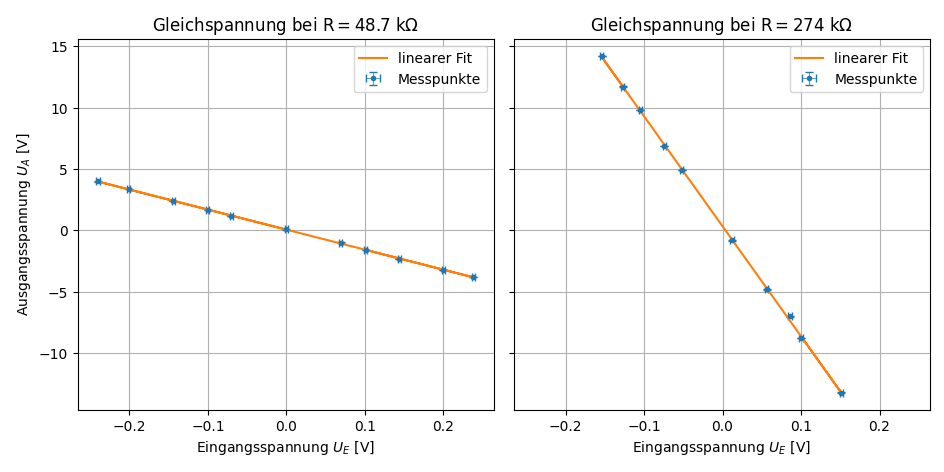

In [123]:
R=[r'48.7 k$\Omega$',r'274 k$\Omega$']
U='Gleichspannung'
U_E=[0.001*np.array([101,144,200,238,69,-70,-100,-144,-201,-240,0]),0.001*np.array([100.0,151.0,86.0,56.0,12.0,-52.0,-74.0,-105.0,-154.0,-127.0])]
Delta_U_E=0.002
U_A=[np.array([-1.60,-2.32,-3.20,-3.8,-1.0,1.18,1.67,2.40,3.36,3.99,0.09]),np.array([-8.77,-13.20,-7.0,-4.79,-0.8,4.94,6.89,9.81,14.20,11.70])]
Delta_U_A=0.02
fig, axes = plt.subplots(1, 2, figsize=(figsize_cm(12,6)),sharey=True,sharex=True)
axes[0].set_ylabel(r'Ausgangsspannung $U_A$ [V]')

for i,ax in enumerate(axes):
    ax.set_xlabel(r'Eingangsspannung $U_E$ [V]')
    ax.set_title(rf'{U} bei R$=${R[i]}')
    ax.errorbar(U_E[i],U_A[i],yerr=Delta_U_A,xerr=Delta_U_E, fmt=".",capsize=3,elinewidth=0.5,label=r'Messpunkte')
    def lin(x,a,c):
        return x*a+c
    popt, pcov=curve_fit(lin, U_E[i],U_A[i],sigma=Delta_U_A,absolute_sigma=True)
    ax.plot(U_E[i],lin(U_E[i],*popt),r'-',label='linearer Fit')
    print(rf'V_{{DC_{i+1}}}'+round_to_sigs(popt[0],np.sqrt(pcov[0][0]),einheiten='')[3])
    ax.legend()
    ax.grid()


plt.tight_layout()
plt.show()
plt.savefig(Ausgabe_path/"Nr.1_Gleichspannung.png",format="png")


V_{AC_1}\qty{81.2(0.3)}{}
V_{AC_2}\qty{207.8(0.3)}{}


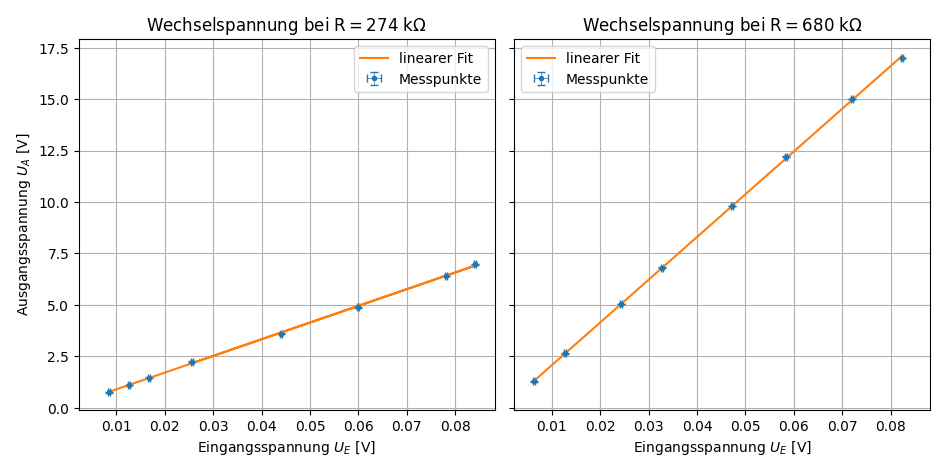

In [119]:
R=[r'274 k$\Omega$',r'680 k$\Omega$',]
U='Wechselspannung'
U_E=[0.0001*np.array([84,126,168,440,780,840,600,256]),0.0001*np.array([64,128,244,328,472,584,720,824])]
Delta_U_E=0.0002
U_A=[np.array([0.740,1.1,1.46,3.6,6.4,6.96,4.88,2.24]),np.array([1.28,2.64,5.04,6.80,9.80,12.2,15.0,17.0])]
Delta_U_A=0.02

plt.close('all')
fig, axes = plt.subplots(1, 2, figsize=(figsize_cm(12,6)),sharey=True,sharex=True)
axes[0].set_ylabel(r'Ausgangsspannung $U_A$ [V]')
for i,ax in enumerate(axes):
    ax.set_xlabel(r'Eingangsspannung $U_E$ [V]')
    ax.set_title(rf'{U} bei R$=${R[i]}')
    ax.errorbar(U_E[i],U_A[i],yerr=Delta_U_A,xerr=Delta_U_E, fmt=".",capsize=3,elinewidth=0.5,label=r'Messpunkte')
    def lin(x,a,c):
        return x*a+c
    popt, pcov=curve_fit(lin, U_E[i],U_A[i],sigma=Delta_U_A,absolute_sigma=True)
    ax.plot(U_E[i],lin(U_E[i],*popt),r'-',label='linearer Fit')
    ax.legend()
    ax.grid()
    
    print(rf'V_{{AC_{i+1}}}'+round_to_sigs(popt[0],np.sqrt(pcov[0][0]),einheiten='')[3])


plt.tight_layout()
plt.show()
plt.savefig(Ausgabe_path/"Nr.1_Wechselspannung.png",format="png")


In [128]:
R_e=3000
Delta_R_e=0.1*R_e
R_g=1000*np.array([48.0,274.0,274.0,680.0])
Delta_R_g=0.1*R_g
V=R_g/R_e
Delta_V=V*np.sqrt(Delta_R_e**2/R_e**2 + Delta_R_g**2/R_g**2)
V,Delta_V,_,latexqty=v_round(V,Delta_V,einheiten='')
for i in range(len(V)):
    print(latexqty[i])


\qty{16.0(2.3)}{}
\qty{91(13)}{}
\qty{91(13)}{}
\qty{230(40)}{}


In [102]:
gff("R_g/R_e","R_e,R_g")

Funktion:


<IPython.core.display.Math object>

\frac{R_{g}}{R_{e}}
Absoluter Fehler:


<IPython.core.display.Math object>

\sqrt{\frac{\Delta_{R e}^{2} R_{g}^{2} + \Delta_{R g}^{2} R_{e}^{2}}{R_{e}^{4}}}
Relativer Fehler:


<IPython.core.display.Math object>

\sqrt{\frac{\Delta_{R e}^{2}}{R_{e}^{2}} + \frac{\Delta_{R g}^{2}}{R_{g}^{2}}}


(R_g/R_e,
 sqrt((Delta_R_e**2*R_g**2 + Delta_R_g**2*R_e**2)/R_e**4),
 sqrt(Delta_R_e**2/R_e**2 + Delta_R_g**2/R_g**2),
 [(R_e, Delta_R_e), (R_g, Delta_R_g)])

In [129]:
U_Messung=np.array([16.31,89.57,81.2,207.8])
Delta_U_Messung=np.array([0.04,0.07,0.3,0.3])
compare_table_array(r'V\'exp',r'V\'theo',r'\volt',U_Messung,Delta_U_Messung,V,Delta_V)

\begin{table}[htb]
\centering
\caption{Vergleich von V\'exp und V\'theo}
\begin{tabularx}{0.8\textwidth}{ZZZZZ}
    \toprule
         Messreihe & V\'exp[\unit{\volt}] & V\'theo[\unit{\volt}] & \text{abs.Abw.}[\unit{\volt}] & \text{proz.Abw.}[\unit{\percent}] & S[\sigma] \\\midrule
        & \num{16.31(0.04)} & \num{16.0(2.3)} & \num{0.3(2.4)} & \num{2(15)} & \num{0.14} \\
        & \num{89.57(0.07)} & \num{91(13)} & \num{1(14)} & \num{2(15)} & \num{0.11} \\
        & \num{81.2(0.3)} & \num{91(13)} & \num{10(14)} & \num{12(17)} & \num{0.8} \\
        & \num{207.8(0.3)} & \num{230(40)} & \num{20(50)} & \num{11(20)} & \num{0.6} \\
\bottomrule
\end{tabularx}
\label{table:Vergleich_V\'exp} 
\end{table}


Nr.2


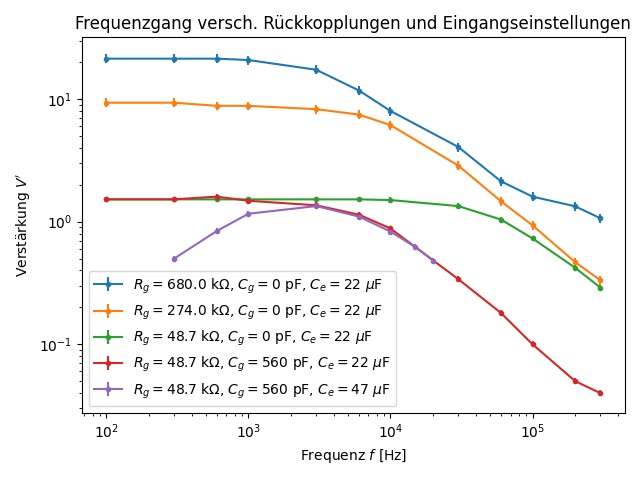

In [ ]:
#Berechnung der Verstärkungen
R_g=np.array([680,274,48.7,48.7,48.7])
C_e=np.array([22,22,22,22,47])
C_g=np.array([0,0,0,560,560])
U_SS=np.array([0.3,0.3,1.0,1.0,1.0])    
Delta_U_SS=0.02

f_1_4=np.array([100,300,600,1000,3e3,6e3,1e4,3e4,6e4,1e5,2e5,3e5])
f_5=np.array([300,600,1000,3e3,6e3,1e4,1.5e4,2e4])

U_A_1_4=[np.array([6.4,6.4,6.4,6.24,5.20,3.52,2.40,1.22,0.64,0.48,0.4,0.32]),np.array([2.8,2.8,2.64,2.64,2.48,2.24,1.84,0.86,0.44,0.28,0.14,0.1]),np.array([1.52,1.52,1.52,1.52,1.52,1.52,1.50,1.34,1.04,0.73,0.42,0.29]),np.array([1.52,1.52,1.60,1.48,1.36,1.14,0.88,0.34,0.18,0.10,0.05,0.04]),np.array([0.5,0.84,1.16,1.34,1.10,0.83,0.62,0.48])]
Delta_U_A = 0.05

plt.close('all')
plt.title('Frequenzgang versch. Rückkopplungen und Eingangseinstellungen')
plt.xlabel('Frequenz $f$ [Hz]')
plt.ylabel('Verstärkung $V\'$')

for i in range(5):
    V=U_A_1_4[i]/U_SS[i]
    Delta_V=V*np.sqrt(Delta_U_A**2+(Delta_U_SS / U_SS[i])**2)
    if i<4:
        plt.errorbar(f_1_4,V,yerr=Delta_V,fmt='.',linestyle='-',label=rf'$R_g=${R_g[i]} k$\Omega$, $C_g=${C_g[i]} pF, $C_e=${C_e[i]} $\mu$F')
    else:
        plt.errorbar(f_5,V,yerr=Delta_V,fmt='.',linestyle='-',label=rf'$R_g=${R_g[i]} k$\Omega$, $C_g=${C_g[i]} pF, $C_e=${C_e[i]} $\mu$F')

plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.savefig(Ausgabe_path/"Nr.Frequenzgang.png",format="png")
plt.show()


In [105]:
gff("U_A/U_SS","U_A,U_SS")

Funktion:


<IPython.core.display.Math object>

\frac{U_{A}}{U_{SS}}
Absoluter Fehler:


<IPython.core.display.Math object>

\sqrt{\frac{\Delta_{U A}^{2} U_{SS}^{2} + \Delta_{U SS}^{2} U_{A}^{2}}{U_{SS}^{4}}}
Relativer Fehler:


<IPython.core.display.Math object>

\sqrt{\frac{\Delta_{U A}^{2}}{U_{A}^{2}} + \frac{\Delta_{U SS}^{2}}{U_{SS}^{2}}}


(U_A/U_SS,
 sqrt((Delta_U_A**2*U_SS**2 + Delta_U_SS**2*U_A**2)/U_SS**4),
 sqrt(Delta_U_A**2/U_A**2 + Delta_U_SS**2/U_SS**2),
 [(U_A, Delta_U_A), (U_SS, Delta_U_SS)])